# Init

In [1]:
import sys
sys.path.append("/home/ed31/Documents/LargeSystem/npc")

import pickle
import matplotlib.pyplot as plt
from trj_ana_tool import *

/home/ed31/miniforge3/envs/md/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [2]:
params={'font.family':'sans-serif',
        'font.sans-serif':'Arial',
        'font.weight':'normal', # or 'blod'
        'figure.figsize': [3.2, 2.4],
        'font.size': 12, # or large,small
        'axes.titlesize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize':10,
        'figure.dpi': 300,
        'lines.linewidth': 1.2,
        'mathtext.fontset': 'custom',
        'mathtext.rm': 'Arial',
        'mathtext.it': 'Arial:italic',
        'mathtext.cal': 'Times New Roman:italic',
        'mathtext.tt': 'Times New Roman',
        'mathtext.sf': 'Nimbus Sans',
        "legend.frameon": False,
        'savefig.dpi': 300,
        'savefig.transparent': True,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.02
        }
plt.rcParams.update(params)

In [3]:
def label(string, fig = None, transform = None, x = -0.1, y = 1.05):
    if fig == None:
        fig = plt.gcf()
    if transform == None:
        transform = plt.gca().transAxes

    fig.text(x, y, string, transform=transform) 

In [4]:
VMDcolor = {
    'magenta': (0.9, 0.0, 0.9), 
    'blue': (0.0, 0.0, 1.0), 
    # 'blue': (0.0, 0.0, 0.8), 
    # 'lime': (0.5, 0.9, 0.4),
    'lime': (0.4, 0.72, 0.32),
    'orange3': (0.96, 0.72, 0.0),
    'silver': (0.6, 0.6, 0.6),
    'violet': (0.45, 0.0, 0.9),
    # Others
    # cyan: (0.0, 1.0, 1.0)
    # cyan3: (0.0, 0.4, 0.5)
}


dic_ring = {'CR_all': VMDcolor['magenta'],
    'IR_all': VMDcolor['blue'],
    'NR_all': VMDcolor['lime'],
    'LR_all': VMDcolor['orange3'],
    'Bridge': VMDcolor['silver']}
list_ring = ['CR_all', 'IR_all', 'NR_all', 'LR_all', 'Bridge']

In [ ]:
# This list is for the perturbed Hamiltonians
color_list = ['red', 'gray', 'gold', 'lightpink']

In [6]:
import matplotlib
for color in color_list:
    print(color, matplotlib.colors.to_rgb(color),matplotlib.colors.to_hex(color))
# matplotlib.colors.to_rgb('purple')

red (1.0, 0.0, 0.0) #ff0000
gray (0.5019607843137255, 0.5019607843137255, 0.5019607843137255) #808080
gold (1.0, 0.8431372549019608, 0.0) #ffd700
lightpink (1.0, 0.7137254901960784, 0.7568627450980392) #ffb6c1


In [7]:
# spoke_color = plt.get_cmap('viridis', 10).colors[1:-1]
spoke_color = plt.get_cmap('berlin', 8).colors

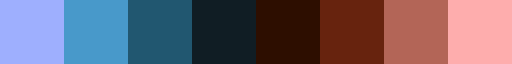

In [8]:
plt.get_cmap('berlin', 8)

In [ ]:
dt = 5/1e3 # Record every 10**4 steps
end_frame = 7950
end_frame_xlim = 8000

n_step = 20

In [12]:
from matplotlib import colors

# Get RGB from a named color
print(np.array(colors.to_rgb('tab:blue')) * 256) 
print(np.array(colors.to_rgb('tab:orange')) * 256) 
print(np.array(colors.to_rgb('tab:green')) * 256) 
print(np.array(colors.to_rgb('tab:red')) * 256) 

[ 31.12156863 119.46666667 180.70588235]
[256.         127.49803922  14.05490196]
[ 44.17254902 160.62745098  44.17254902]
[214.83921569  39.15294118  40.15686275]


# RMSD & Q

In [13]:
def calculate_cumulative_thresholds(a, N):
    """
    Calculates (a <= i).sum() for all i in [0, 1, ..., N] 
    in a fully vectorized manner.
    """
    # 1. Sort the input array (O(M log M))
    sorted_a = np.sort(a)
    
    # 2. Create the target values i = [0, 1, ..., N]
    i_values = np.arange(N)
    
    # 3. Use binary search to find the count of elements <= i
    # side='right' finds the index where i could be inserted while 
    # maintaining order, which is exactly the count of elements <= i.
    return np.searchsorted(sorted_a, i_values, side='right')

In [14]:
def get_denoised_Q(df_Q, end_frame, Qthresh = 0.7):
    ftime = df_Q.query(f"Q_max > {Qthresh}")['ftime'].to_numpy()
    Q_denoised = calculate_cumulative_thresholds(ftime,end_frame) / len(df_Q)
    return Q_denoised

In [15]:
with open("production_run/cdcrystal_rmsd.pkl", "rb") as f:
    initial_rmsd = pickle.load(f)

In [16]:
with open("production_run/d2c/1/rmsd.pkl", "rb") as f:
    d2c_1_rmsd_1 = pickle.load(f)

In [17]:
d2c_q_form = [None] # start from 1, so the first element is None
for i in range(1, 21):
    with open(f"production_run/d2c/{i}/Q_form.pkl", "rb") as f:
        d2c_q_form.append(pickle.load(f))

In [19]:
intralinker_q_form = [None] # start from 1, so the first element is None
for i in range(1, 11):
    with open(f"production_run/intrachain_linker/{i}/Q_form.pkl", "rb") as f:
        intralinker_q_form.append(pickle.load(f))

In [20]:
irnonlinker_q_form = [None] # start from 1, so the first element is None
for i in range(1, 11):
    with open(f"production_run/intrachain_irnonlinker/{i}/Q_form.pkl", "rb") as f:
        irnonlinker_q_form.append(pickle.load(f))

interlinker_q_form = [None] # start from 1, so the first element is None
for i in range(1, 11):
    with open(f"production_run/interchain_linker/{i}/Q_form.pkl", "rb") as f:
        interlinker_q_form.append(pickle.load(f))


IRinterface_q_form = [None] # start from 1, so the first element is None
for i in range(1, 11):
    with open(f"production_run/IRinterface_weaken/{i}/Q_form.pkl", "rb") as f:
        IRinterface_q_form.append(pickle.load(f))

## Crystal

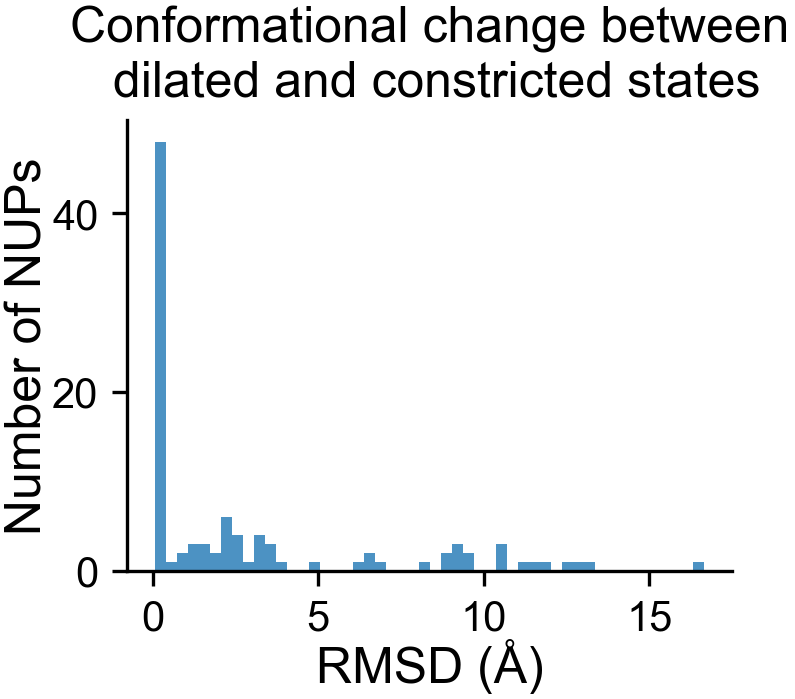

In [21]:
#for idx in (cr_idx, ir_idx, nr_idx, lr_idx, bridge_idx):
plt.figure(figsize=(2.6, 1.95))
plt.hist(initial_rmsd.rmsd_chains[0, :, 0], bins=50, alpha=0.8)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel("RMSD (Å)", labelpad=0)
plt.ylabel("Number of NUPs", labelpad=0)
plt.title("Conformational change between\n dilated and constricted states")
plt.savefig("Figures4pub/rmsd_histogram.svg")

## Linker

In [22]:
rmsd_linkers = np.load("production_run/d2c/1/rmsd_linkers.npy")

In [23]:
rmsd_linkers_intralinker = np.load("production_run/intrachain_linker/1/rmsd_linkers.npy")
rmsd_linkers_interlinker = np.load("production_run/interchain_linker/1/rmsd_linkers.npy")
rmsd_linkers_irnonlinker = np.load("production_run/intrachain_irnonlinker/1/rmsd_linkers.npy")
rmsd_linkers_IRinterface = np.load("production_run/IRinterface_weaken/1/rmsd_linkers.npy")

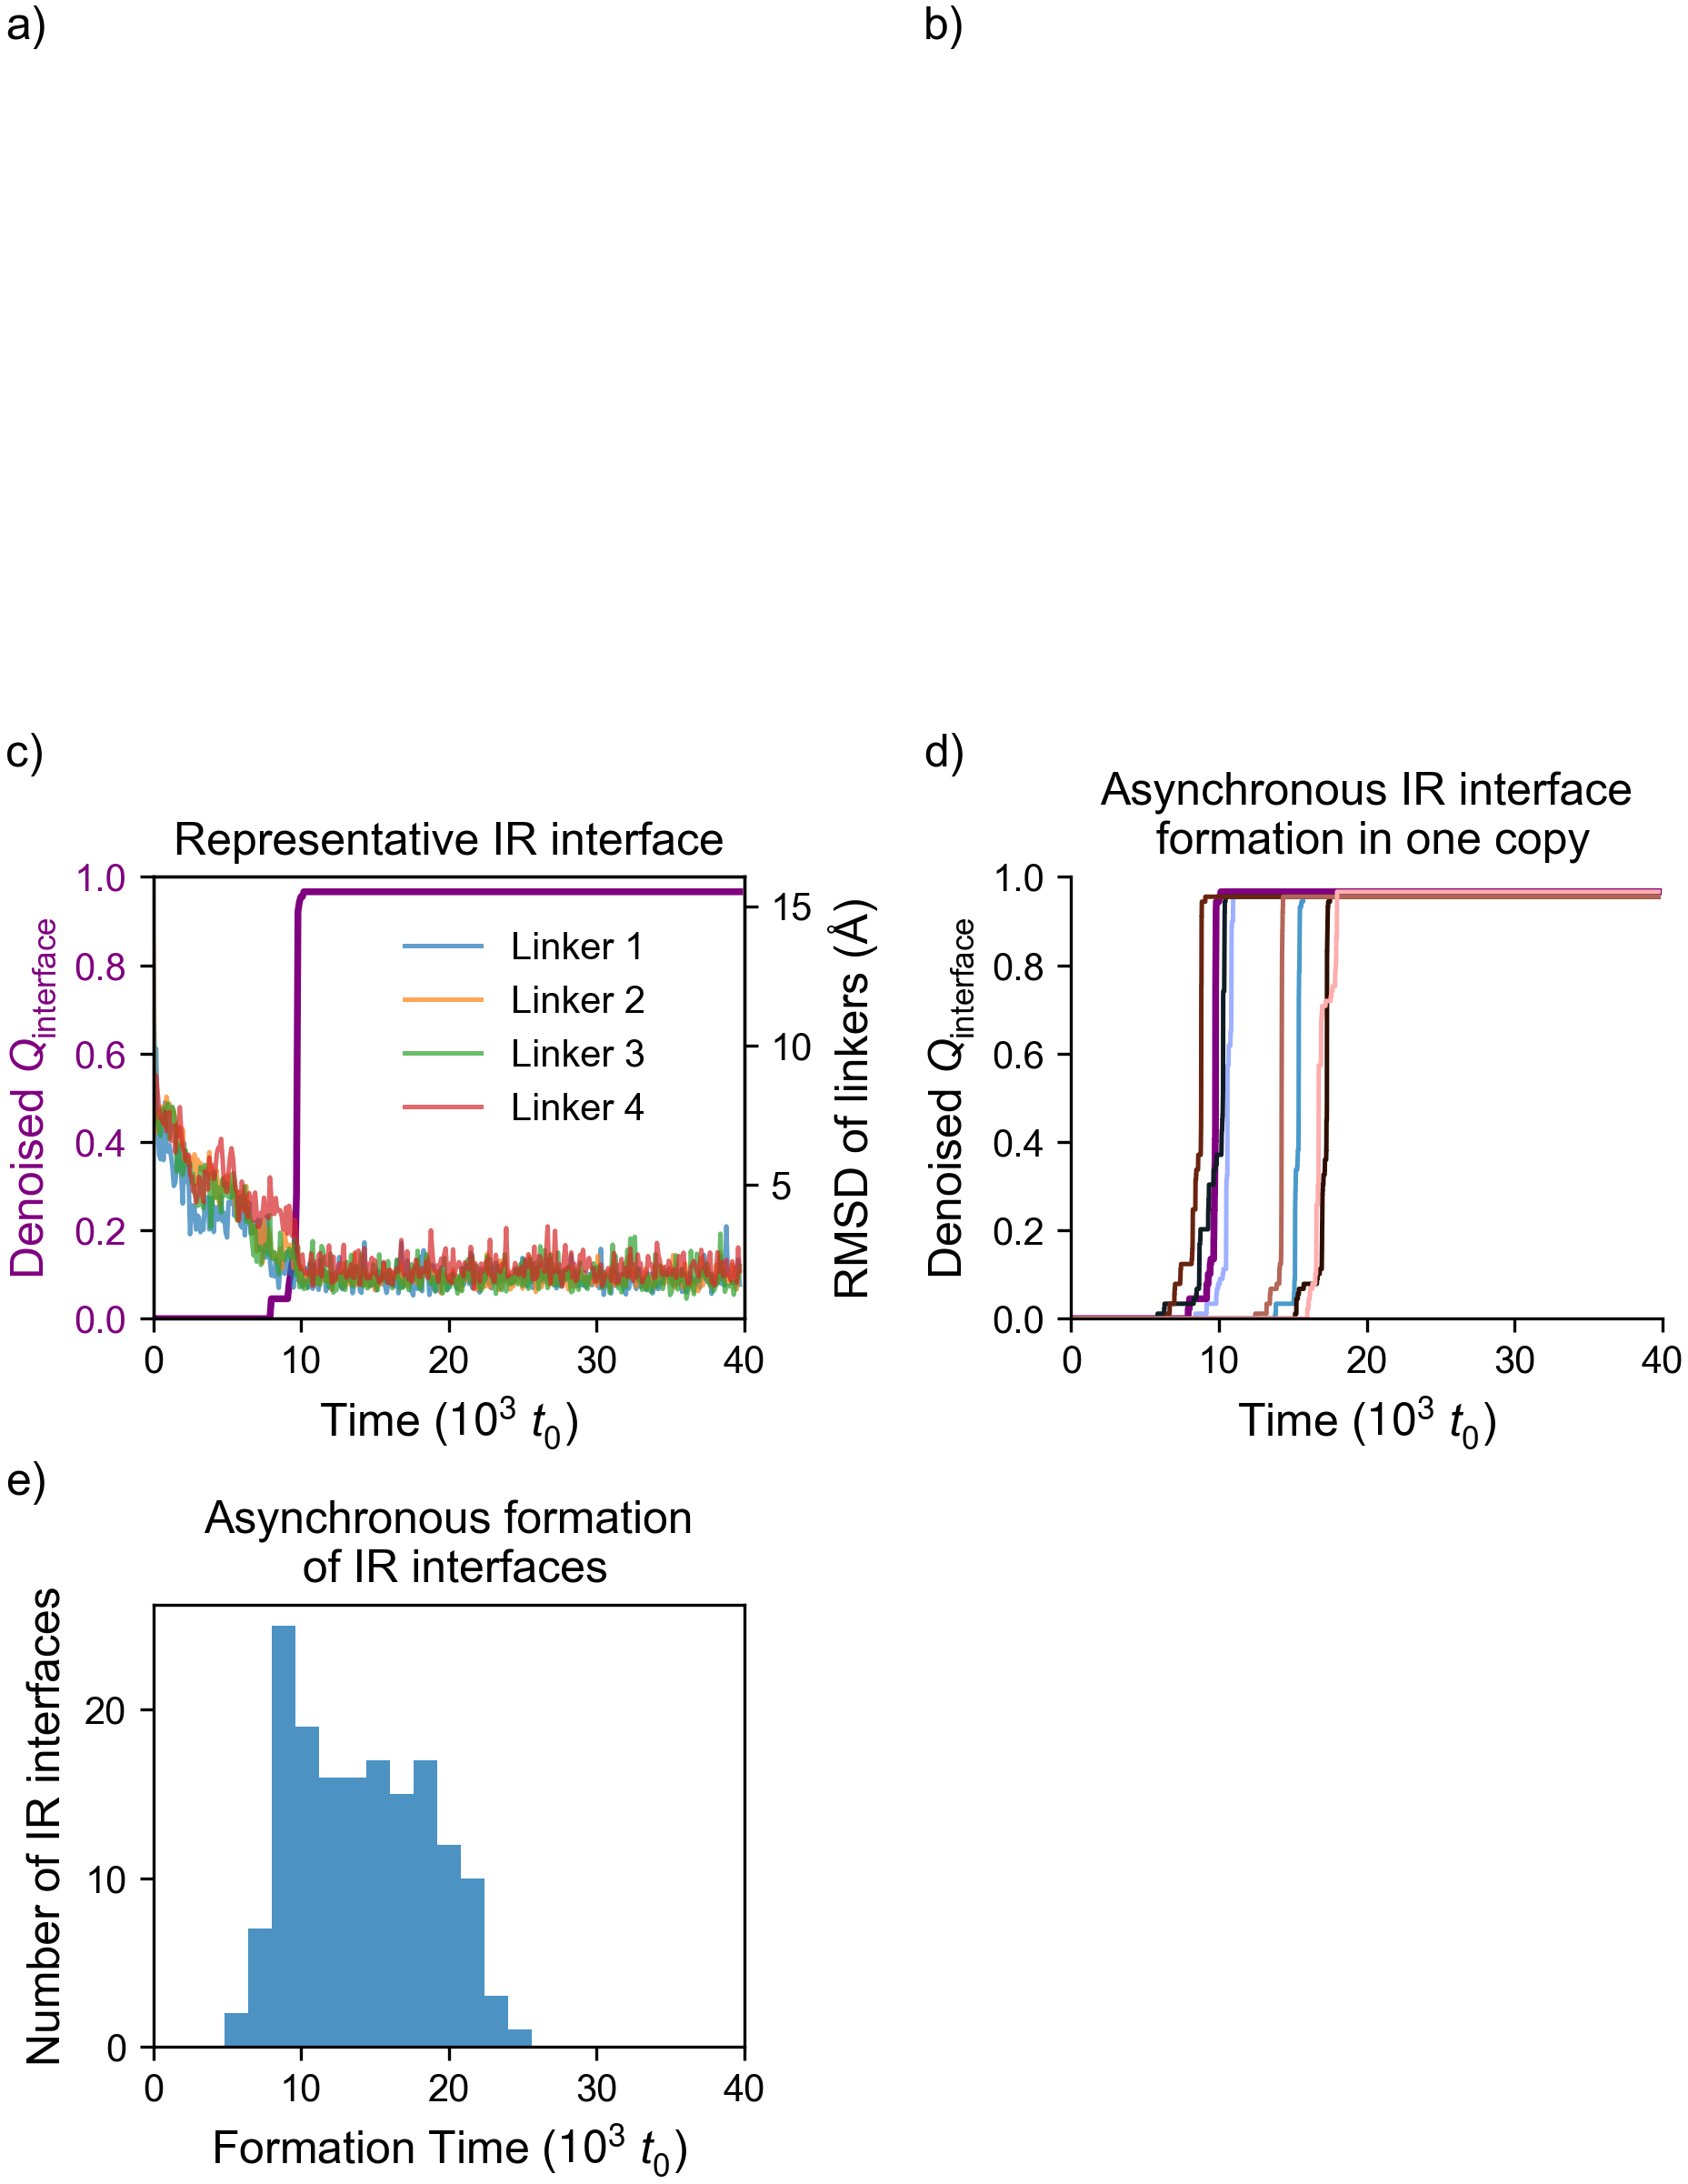

In [ ]:
fig = plt.figure(figsize = (6.5, 7.8))

plt.subplot(3, 2, 1)
plt.axis('off')
label('a)', x = -0.25, y = 1.25)


plt.subplot(3, 2, 2)
plt.axis('off')
label('b)', x = -0.25, y = 1.25)


plt.subplot(3, 2, 3)
interface_idx = 2

copy = 1
q_form_tmp = d2c_q_form[copy].df_Q.query(
    f'(rings == "IR_all-IR_all" & subunit_i == {interface_idx} & subunit_j == {interface_idx+1} )'
)
Q_denoised = get_denoised_Q(q_form_tmp, end_frame)
plt.plot(np.arange(end_frame, step=n_step) * dt, Q_denoised[::n_step], color = "purple", linewidth = 1.8)
plt.xlim(0, end_frame_xlim * dt)
plt.ylim(0, 1)
plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
plt.ylabel(r"Denoised $Q_{\mathrm{interface}}$", color = "purple")
plt.tick_params(axis='y', labelcolor="purple")
plt.title(f"Representative IR interface")
plt.yticks(np.arange(0, 1.1, 0.2))

plt.twinx()

plt.plot(np.arange(end_frame, step=n_step) * dt, rmsd_linkers[:end_frame:n_step, 2:4, interface_idx], alpha = 0.7)
plt.plot(np.arange(end_frame, step=n_step) * dt, rmsd_linkers[:end_frame:n_step, 0:2, interface_idx+1], alpha = 0.7)
plt.ylabel("RMSD of linkers (Å)")
plt.legend(["Linker 1", "Linker 2", "Linker 3", "Linker 4"], loc = [0.4, 0.4], ncol = 1, frameon = False)

label('c)', x = -0.25, y = 1.25)


plt.subplot(3, 2, 4)
copy = 1
for i in range(7):
    q_form_tmp = d2c_q_form[copy].df_Q.query(
        f'rings == "IR_all-IR_all" & subunit_i == {i} & subunit_j == {i+1}'
    )
    Q_denoise = get_denoised_Q(q_form_tmp, end_frame)
    if i == interface_idx:
        plt.plot(np.arange(end_frame) * dt, Q_denoise[:end_frame], color = "purple", linewidth = 1.8)
    else:
        plt.plot(np.arange(end_frame) * dt, Q_denoise[:end_frame], color = spoke_color[i])

q_form_tmp = d2c_q_form[copy].df_Q.query(
    f'rings == "IR_all-IR_all" & subunit_i == 0 & subunit_j == 7'
)
Q_denoise = get_denoised_Q(q_form_tmp, end_frame)
plt.plot(np.arange(end_frame) * dt, Q_denoise[:end_frame], color = spoke_color[7])

# remove top axis
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlim(0, end_frame_xlim * dt)
plt.ylim(0, 1)
plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
plt.ylabel(r"Denoised $Q_{\mathrm{interface}}$")
# plt.tick_params(axis='y', labelcolor="purple")
plt.title(f"Asynchronous IR interface\n formation in one copy")

label('d)', x = -0.25, y = 1.25)


plt.subplot(3, 2, 5)
ftime_list = []
for q_form in d2c_q_form[1:]:
    for i in range(7):
        q_form_tmp = q_form.df_Q.query(
            f'(rings == "IR_all-IR_all" & subunit_i == {i} & subunit_j == {i+1} )'
        )
        Q_denoised = get_denoised_Q(q_form_tmp, end_frame)
        ftime_list.append(len(np.diff(Q_denoised)) - 1 - np.argmax(np.diff(Q_denoised)[::-1]))

    q_form_tmp = q_form.df_Q.query(
        f'(rings == "IR_all-IR_all" & subunit_i == 0 & subunit_j == 7 )'
    )
    Q_denoised = get_denoised_Q(q_form_tmp, end_frame)
    ftime_list.append(len(np.diff(Q_denoised)) - 1 - np.argmax(np.diff(Q_denoised)[::-1]))
plt.hist(np.array(ftime_list) * dt, bins = 25, alpha = 0.8, range = (0, end_frame_xlim * dt))
plt.xlim(0, end_frame_xlim * dt)
plt.xlabel(r"Formation Time ($\mathsf{10^3}~t_0)$")
plt.ylabel("Number of IR interfaces")
plt.title(f"Asynchronous formation\n of IR interfaces")

label('e)', x = -0.25, y = 1.25)

# fig.legend(["Linker 1", "Linker 2", "Linker 3", "Linker 4"], loc = "center", ncol = 4, frameon = False, fontsize = 10)
# fig.legend(["Linker 1", "Linker 2", "Linker 3", "Linker 4"], loc = [0.25, 0.45], ncol = 1, frameon = False)

# plt.subplots_adjust(wspace=0.6, hspace=0.7)
plt.tight_layout()
plt.savefig("Figures4pub/F3_pre.svg")

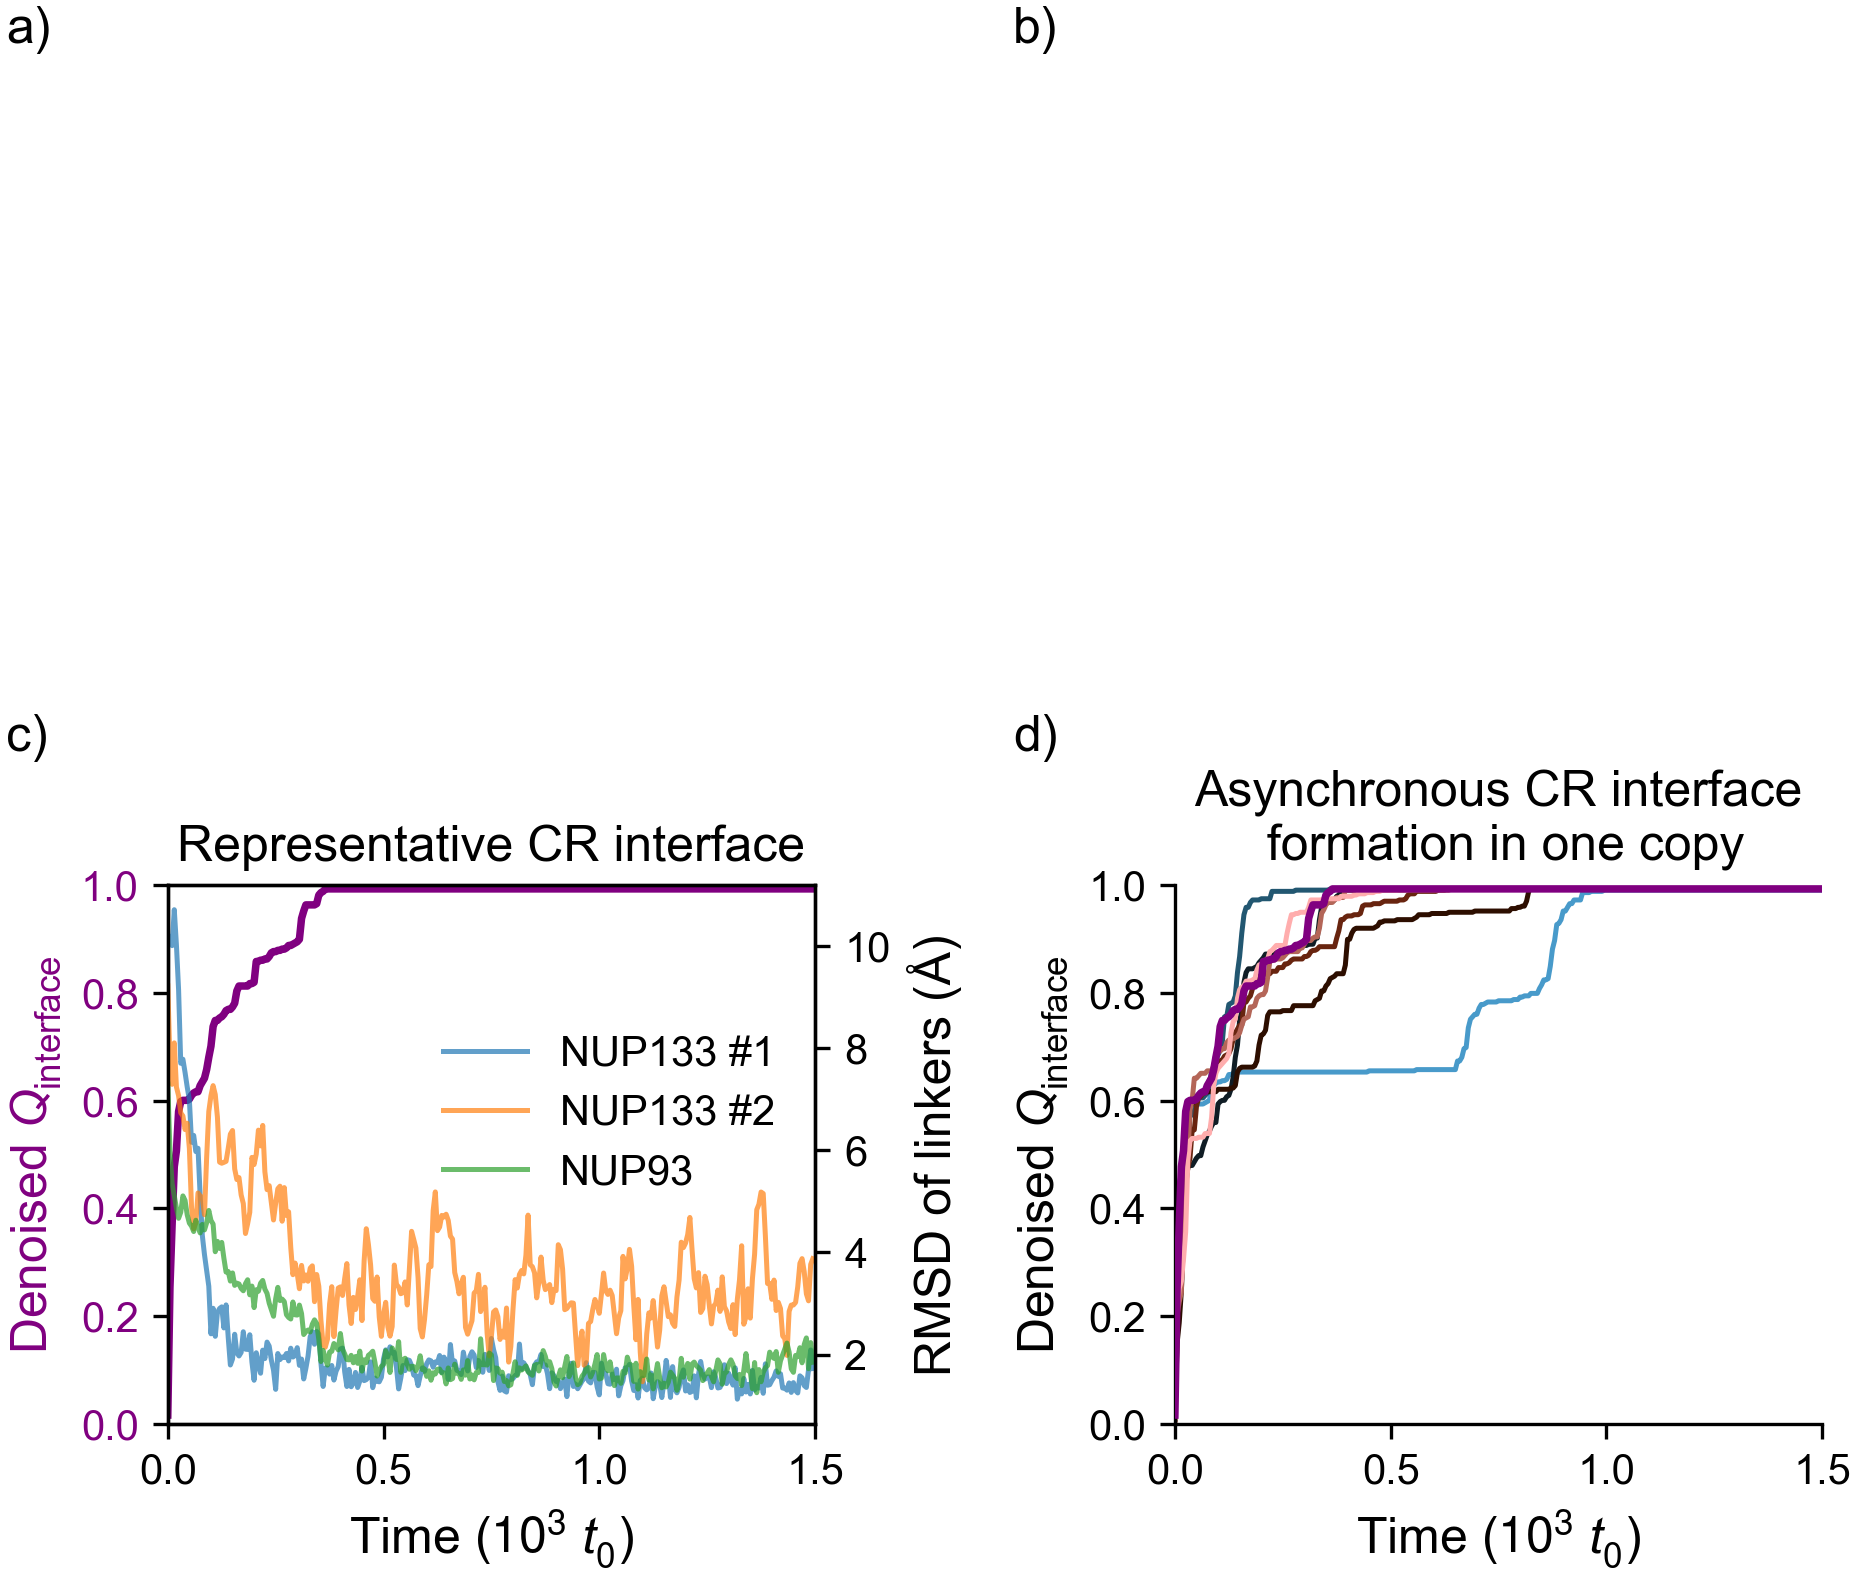

In [ ]:
fig = plt.figure(figsize = (6.5, 5))

plt.subplot(2, 2, 1)
plt.axis('off')
label('a)', x = -0.25, y = 1.25)


plt.subplot(2, 2, 2)
plt.axis('off')
label('b)', x = -0.25, y = 1.25)


plt.subplot(2, 2, 3)
copy = 1
interface_idx = 0
end_frame_test = 300

q_form_tmp = d2c_q_form[copy].df_Q.query(
    f'(rings == "CR_all-CR_all" & subunit_i == {interface_idx} & subunit_j == {interface_idx+1} )'
)
Q_denoised = get_denoised_Q(q_form_tmp, end_frame_test)
plt.plot(np.arange(end_frame_test) * dt, Q_denoised, color = "purple", linewidth = 1.8)
plt.xlim(0, end_frame_test * dt)
plt.ylim(0, 1)
plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
plt.ylabel(r"Denoised $Q_{\mathrm{interface}}$", color = "purple")
plt.tick_params(axis='y', labelcolor="purple")
plt.title(f"Representative CR interface")
plt.yticks(np.arange(0, 1.1, 0.2))

plt.twinx()

plt.plot(np.arange(end_frame_test) * dt, d2c_1_rmsd_1.rmsd_chains[:end_frame_test, 54:56, interface_idx], alpha = 0.7)
plt.plot(np.arange(end_frame_test) * dt, d2c_1_rmsd_1.rmsd_chains[:end_frame_test, 20, interface_idx+1], alpha = 0.7)
plt.ylabel("RMSD of linkers (Å)")
plt.legend(["NUP133 #1", "NUP133 #2", "NUP93"], loc = [0.4, 0.4], ncol = 1, frameon = False)
label('c)', x = -0.25, y = 1.25)


plt.subplot(2, 2, 4)
copy = 1
end_frame_test = 300
interface_idx = 0

for i in range(7):
    q_form_tmp = d2c_q_form[copy].df_Q.query(
        f'rings == "CR_all-CR_all" & subunit_i == {i} & subunit_j == {i+1}'
    )
    Q_denoise = get_denoised_Q(q_form_tmp, end_frame)
    if i == interface_idx:
        plt.plot(np.arange(end_frame_test) * dt, Q_denoise[:end_frame_test], color = "purple", linewidth = 1.8, zorder = 10)
    else:
        plt.plot(np.arange(end_frame_test) * dt, Q_denoise[:end_frame_test], color = spoke_color[i])

q_form_tmp = d2c_q_form[copy].df_Q.query(
    f'rings == "CR_all-CR_all" & subunit_i == 0 & subunit_j == 7'
)
Q_denoise = get_denoised_Q(q_form_tmp, end_frame)
plt.plot(np.arange(end_frame_test) * dt, Q_denoise[:end_frame_test], color = spoke_color[7])


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlim(0, end_frame_test * dt)
plt.ylim(0, 1)
plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
plt.ylabel(r"Denoised $Q_{\mathrm{interface}}$")

# plt.tick_params(axis='y', labelcolor="purple")
plt.title(f"Asynchronous CR interface\n formation in one copy")

label('d)', x = -0.25, y = 1.25)


plt.tight_layout()
plt.savefig("Figures4pub/cr_interface.svg")

## Other representative

In [25]:
def plot_rmsd_nup(rmsd, end_frame, idx):
    data = rmsd.rmsd_chains[:end_frame,idx,:]
    for i in range(8):
        plt.plot(np.arange(end_frame)*dt, data[:,i], color = spoke_color[i])
    plt.ylim(0, 15)
    plt.title(df_chain_info.loc[idx]['Nup'].upper())
    # plt.show()

In [26]:
df_chain_info.loc[32:34]

,new_id,model,start,end,CA_start,CA_end,Nup,Chain ID,Ring
32,D3,7r5k,331135,341497,42131,43442,Nup155,GA,IR
33,D4,7r5k,341498,351860,43443,44754,Nup155,HA,CR-IR bridge
34,D5,7r5k,351861,362223,44755,46066,Nup155,IA,NR-IR bridge


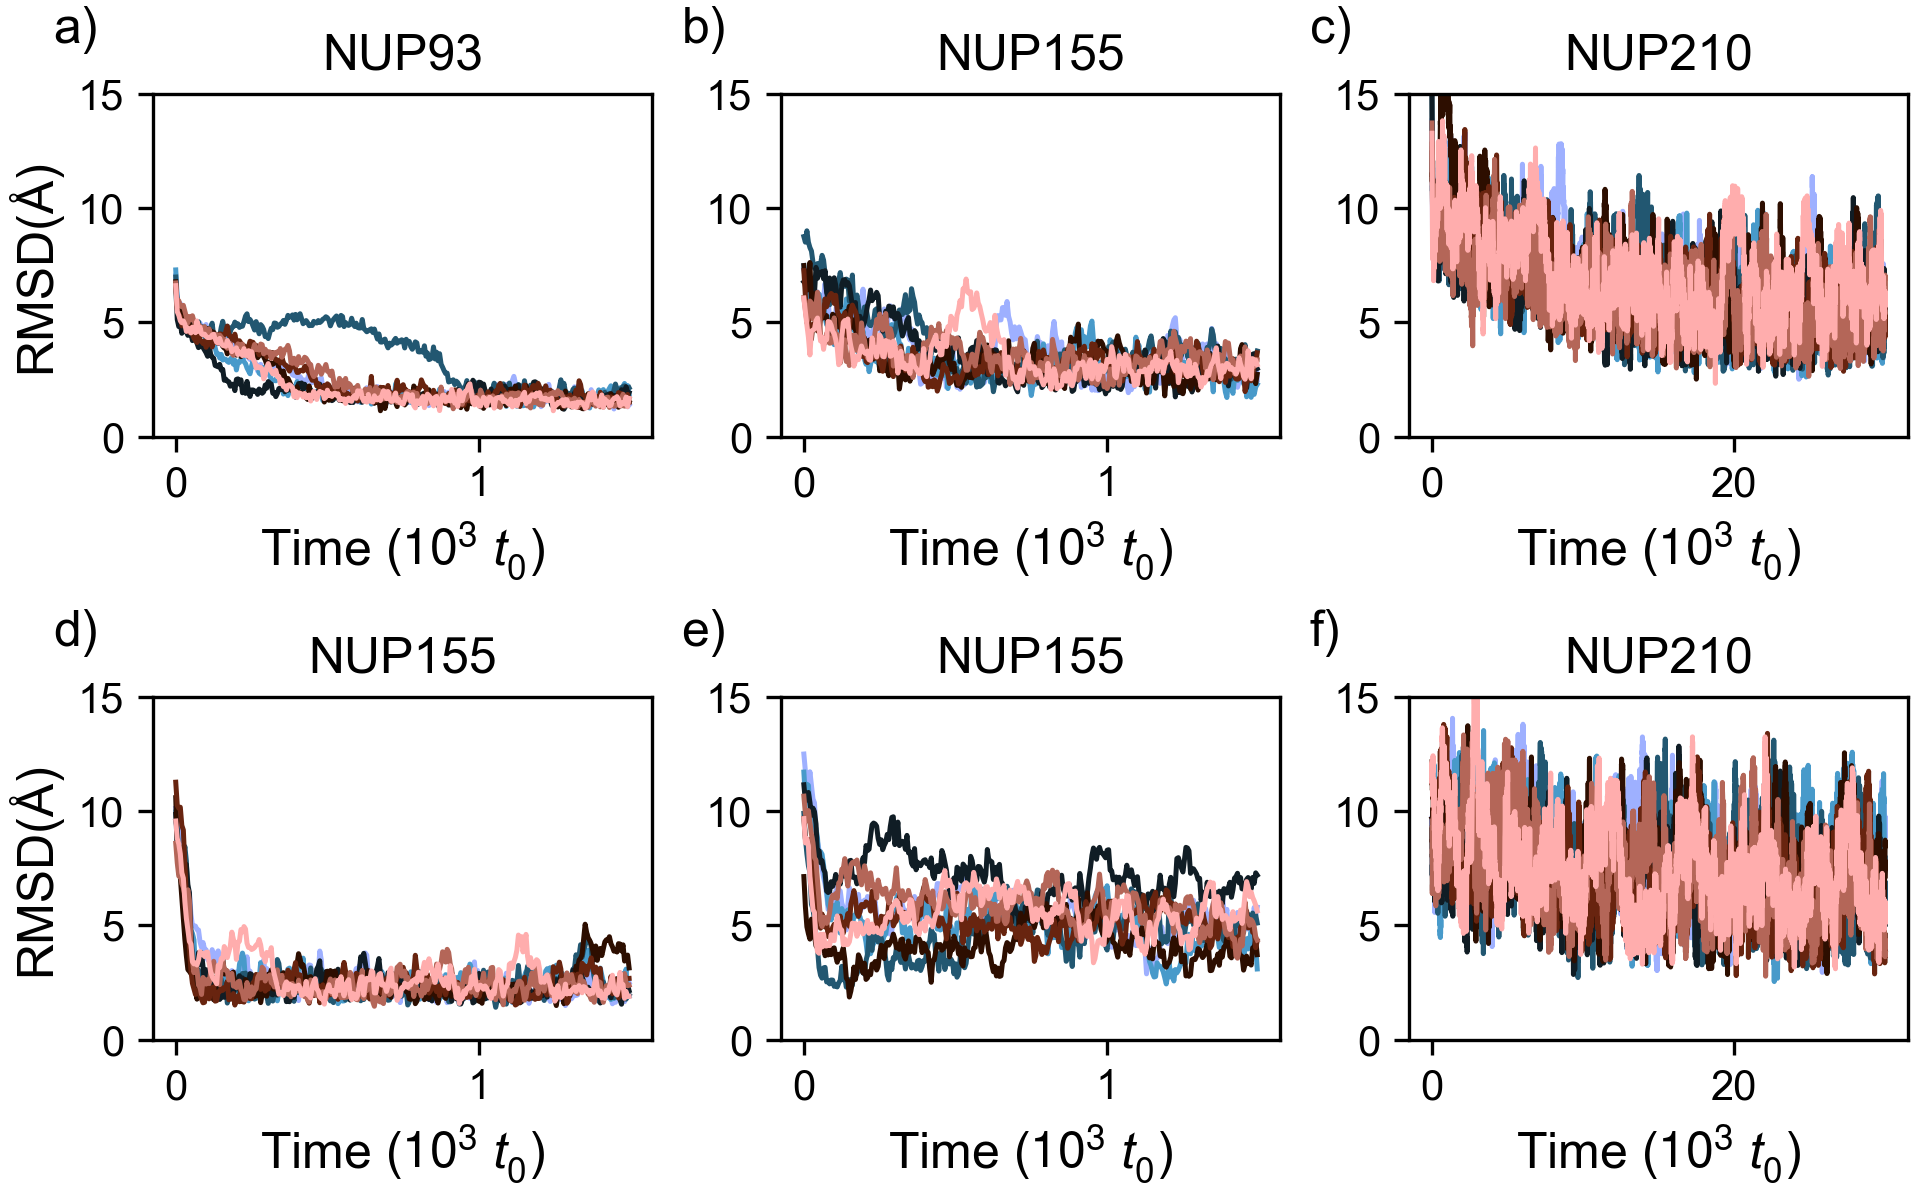

In [27]:
plt.figure(figsize=(6.7, 4.2))

plt.subplot(2,3,1)
plot_rmsd_nup(d2c_1_rmsd_1, end_frame = 300, idx = 20)
plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
plt.ylabel("RMSD(Å)")
label('a)', x = -0.2, y = 1.15)

plt.subplot(2,3,4)
plot_rmsd_nup(d2c_1_rmsd_1, end_frame = 300, idx = 32)
plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
plt.ylabel("RMSD(Å)")
label('d)', x = -0.2, y = 1.15)

plt.subplot(2,3,2)
plot_rmsd_nup(d2c_1_rmsd_1, end_frame = 300, idx = 33)
plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")

label('b)', x = -0.2, y = 1.15)

plt.subplot(2,3,5)
plot_rmsd_nup(d2c_1_rmsd_1, end_frame = 300, idx = 34)
plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
label('e)', x = -0.2, y = 1.15)

plt.subplot(2,3,3)
plot_rmsd_nup(d2c_1_rmsd_1, end_frame = 6000, idx = 5)
plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
plt.title("NUP210")
label('c)', x = -0.2, y = 1.15)

plt.subplot(2,3,6)
plot_rmsd_nup(d2c_1_rmsd_1, end_frame = 6000, idx = 8)
plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
plt.title("NUP210")
label('f)', x = -0.2, y = 1.15)

plt.tight_layout()
plt.savefig("Figures4pub/rmsd_nups.svg")

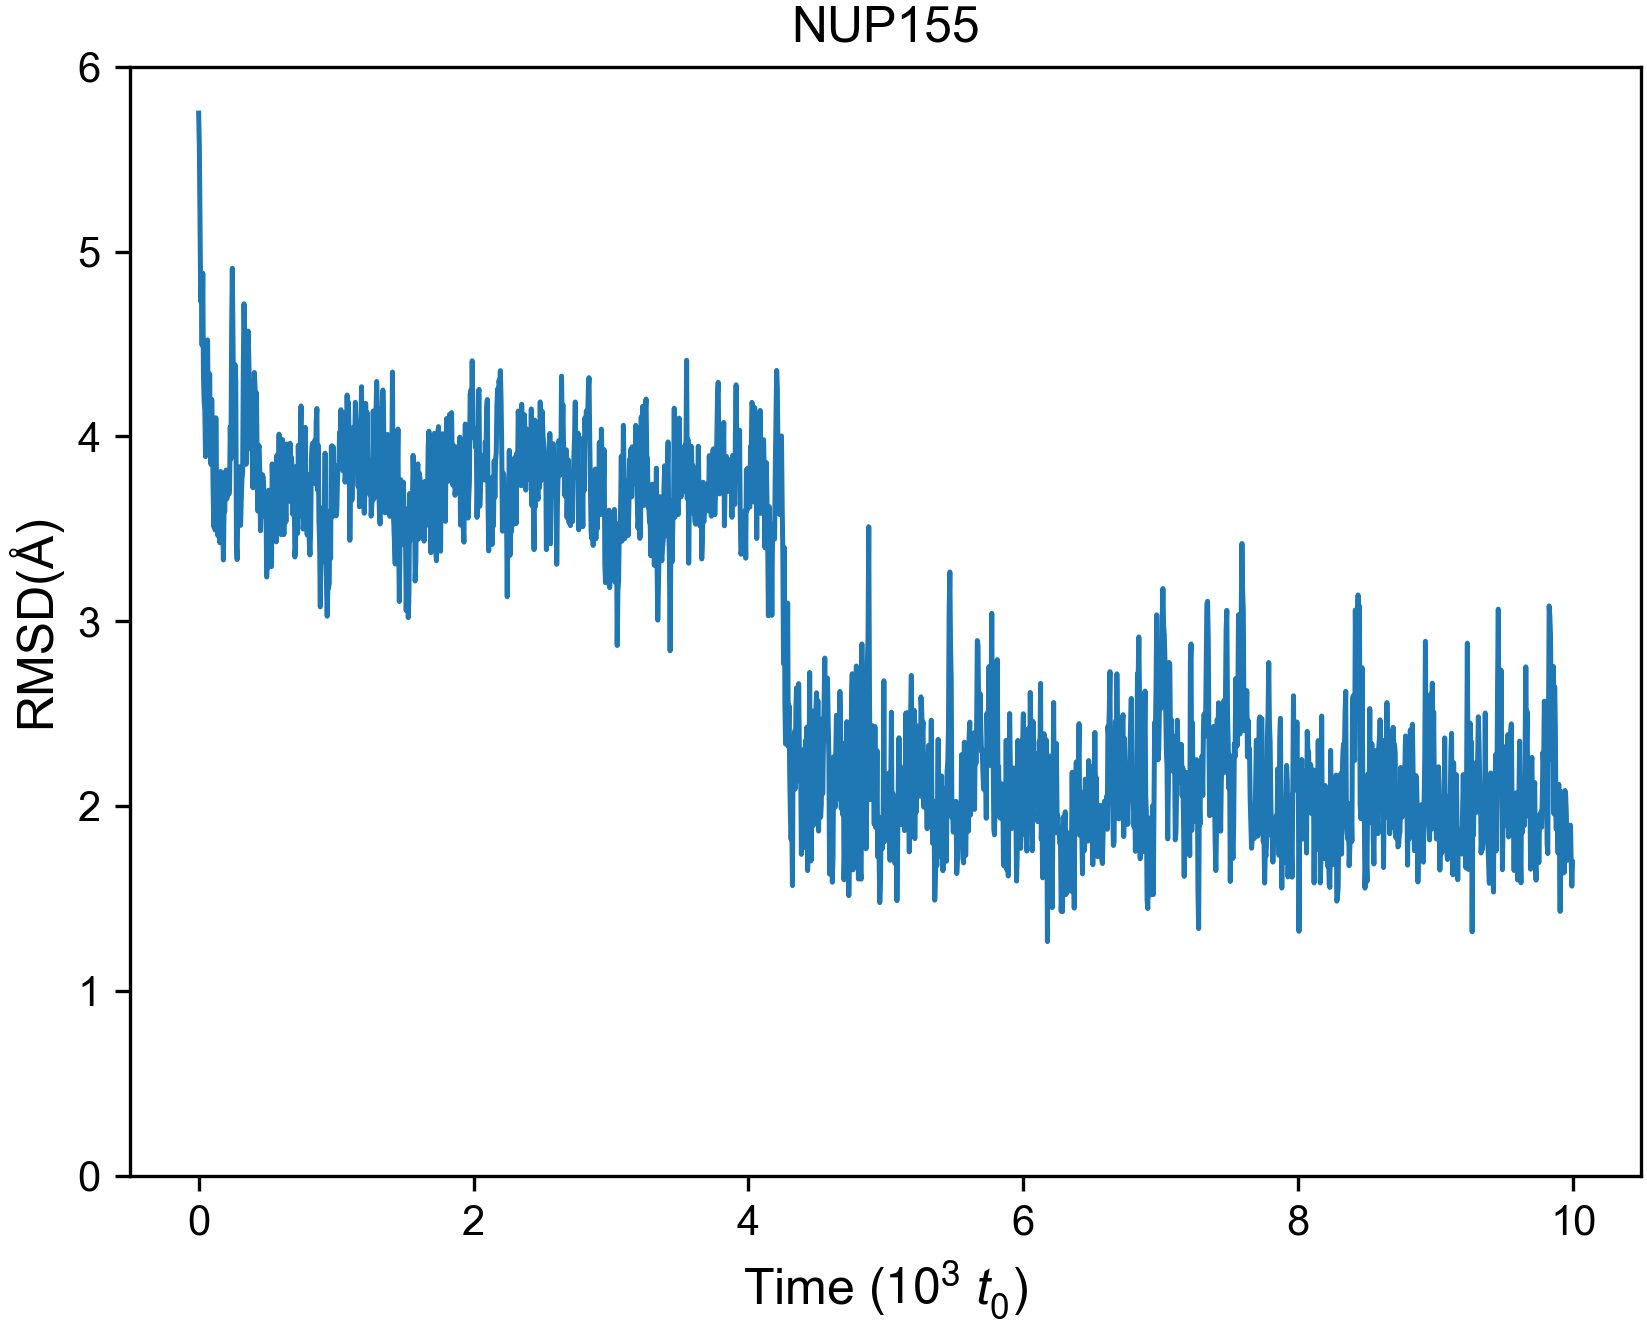

In [28]:
# The only figure using simulation copy 3 (for legacy reasons)
with open("production_run/d2c/3/rmsd.pkl", "rb") as f:
    d2c_1_rmsd_3 = pickle.load(f)
    
plt.figure(figsize=(6.5, 4.8))
plt.plot(np.arange(0, 2000)*dt, d2c_1_rmsd_3.rmsd_chains[:2000,31,7])
plt.ylim(0, 15)
plt.title(df_chain_info.loc[31]['Nup'].upper())
plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
plt.ylabel("RMSD(Å)")
plt.ylim(0, 6)
plt.savefig("Figures4pub/rmsd_nup155_delayed.svg")

# Diameter

In [29]:
def get_ring_com(com_file, mass, dict_chain, ring_info):
    com = np.load(com_file)
    ring_com = {}
    for key in ring_info.keys():
        if key == 'Rings':
            continue
        ring = ring_info[key]

        chain_indices = []
        for chain in ring:
            chain_indices += list(dict_chain[chain])
        chain_indices = np.array(chain_indices)
        # for i in range(1, 8):
        #     chain_indices.append(chain_indices[0] + N_chain_per_subunit *i)
        # chain_indices = np.concatenate(chain_indices)
        # chain_indices = chain_indices.reshape(8, -1)

        # mass_ring = mass[chain_indices].reshape(1, *mass[chain_indices].shape, 1)
        mass_ring = mass[chain_indices]
        # print(mass_ring.shape)
        mass_ring_total = mass_ring.sum()
        # print(mass_ring_total.shape)
        # print(com[:, chain_indices, :].shape)
        
        ring_com[key] = (com[:, chain_indices, :] * mass_ring[:, None, None]).sum(axis = 1) / mass_ring_total
    return ring_com

In [30]:
def get_diameter(diameter_data):
    diameter = []
    for id in range(4):
        diameter.append(np.linalg.norm(diameter_data[:, id] - diameter_data[:, id+4], axis = -1))
    return np.array(diameter).T

In [31]:
chain_range = np.append(df_chain_info['CA_start'].values, [N_subunit_CA])   

mass = np.diff(chain_range)

M_subunit = mass.sum()

In [32]:
ring_com_native = get_ring_com("production_run/cdcrystal_COM.npy", mass, dict_chain, ring_info)

In [33]:
ring_com_d2c =\
[None] + [get_ring_com(f"production_run/d2c/{i}/chain_COM_fit2c.npy", mass, dict_chain, ring_info) for i in range(1,21)]

In [34]:
ring_com_IRinterface = [None] + [get_ring_com(f"production_run/IRinterface_weaken/{i}/chain_COM_fit2c.npy", mass, dict_chain, ring_info) for i in range(1, 11)]

In [35]:
ring_com_intrachain_linker = [None] + [get_ring_com(f"production_run/intrachain_linker/{i}/chain_COM_fit2c.npy", mass, dict_chain, ring_info) for i in range(1, 11)]

In [36]:
ring_com_interchain_linker = [None] + [get_ring_com(f"production_run/interchain_linker/{i}/chain_COM_fit2c.npy", mass, dict_chain, ring_info) for i in range(1, 11)]

In [37]:
ring_com_irnonlinker = [None] + [get_ring_com(f"production_run/intrachain_irnonlinker/{i}/chain_COM_fit2c.npy", mass, dict_chain, ring_info) for i in range(1, 11)]

In [38]:
ring_com_bridge_dual = [None] + [get_ring_com(f"production_run/bridge_dualbasin/{i}/chain_COM_fit2c.npy", mass, dict_chain, ring_info) for i in range(1, 11)]

In [39]:
print("d2c: ", np.min([sim['IR_all'].shape[0] for sim in ring_com_d2c[1:]]))
print("IRinterface: ", np.min([sim['IR_all'].shape[0] for sim in ring_com_IRinterface[1:]]))
print("intrachain_linker: ", np.min([sim['IR_all'].shape[0] for sim in ring_com_intrachain_linker[1:]]))
print("interchain_linker: ", np.min([sim['IR_all'].shape[0] for sim in ring_com_interchain_linker[1:]]))
print("irnonlinker: ", np.min([sim['IR_all'].shape[0] for sim in ring_com_irnonlinker[1:]]))
print("bridge_dual: ", np.min([sim['IR_all'].shape[0] for sim in ring_com_bridge_dual[1:]]))

d2c:  8001
IRinterface:  8001
intrachain_linker:  8854
interchain_linker:  8001
irnonlinker:  8001
bridge_dual:  10367


## Original diameters

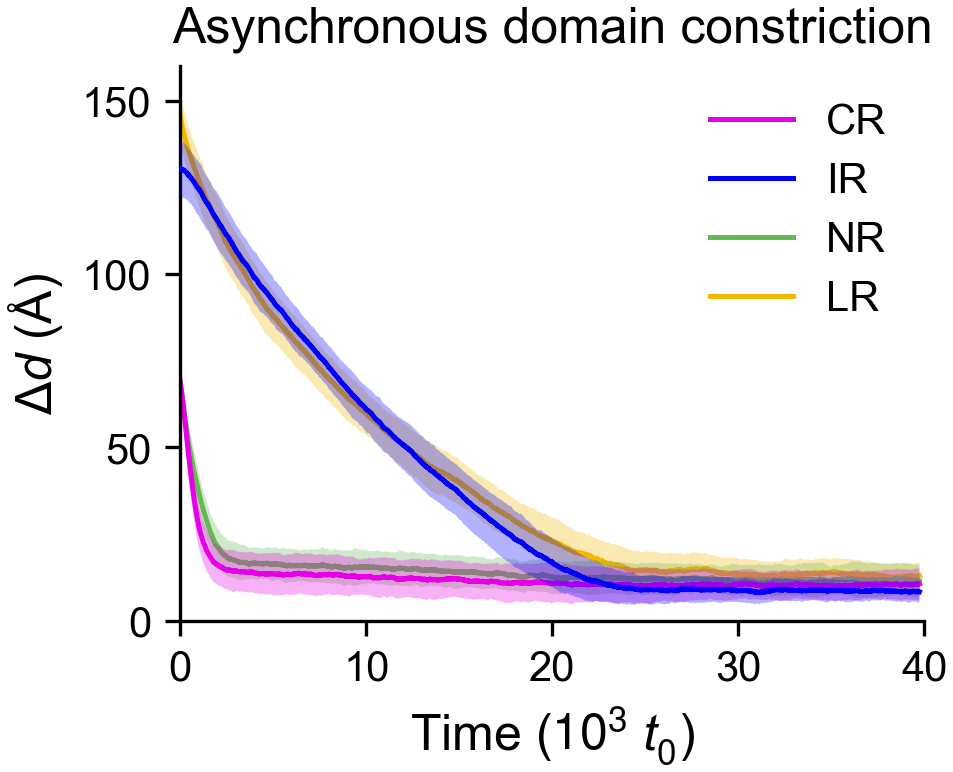

In [46]:
zorder = {
        'CR_all': 2,
        'IR_all': 3,
        'NR_all': 1,
        'LR_all': 0,
}
for key in ('CR_all', 'IR_all', 'NR_all', 'LR_all'):
    d = np.hstack([get_diameter(ring_com_sim[key])[:end_frame] for ring_com_sim in ring_com_d2c[1:]]) -\
        get_diameter(ring_com_native[key]).mean(axis = 1)[1]

    d_mean = d.mean(axis = 1)
    d_std = d.std(ddof = 1, axis = 1)
    
    plt.plot(np.arange(end_frame) * dt, d_mean, label = key[:2], color = dic_ring[key], zorder = zorder[key])
    plt.fill_between(
        np.arange(end_frame) * dt,
        d_mean - d_std,
        d_mean + d_std,
        facecolor = dic_ring[key], alpha = 0.3, zorder = zorder[key]
    )

# remove top axis
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlim(0, end_frame_xlim * dt)
plt.ylim(0, 160)
plt.legend()
plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
plt.ylabel(r"$\Delta d$ (Å)")
plt.title("Asynchronous domain constriction")
plt.savefig("Figures4pub/diameter_change.svg")

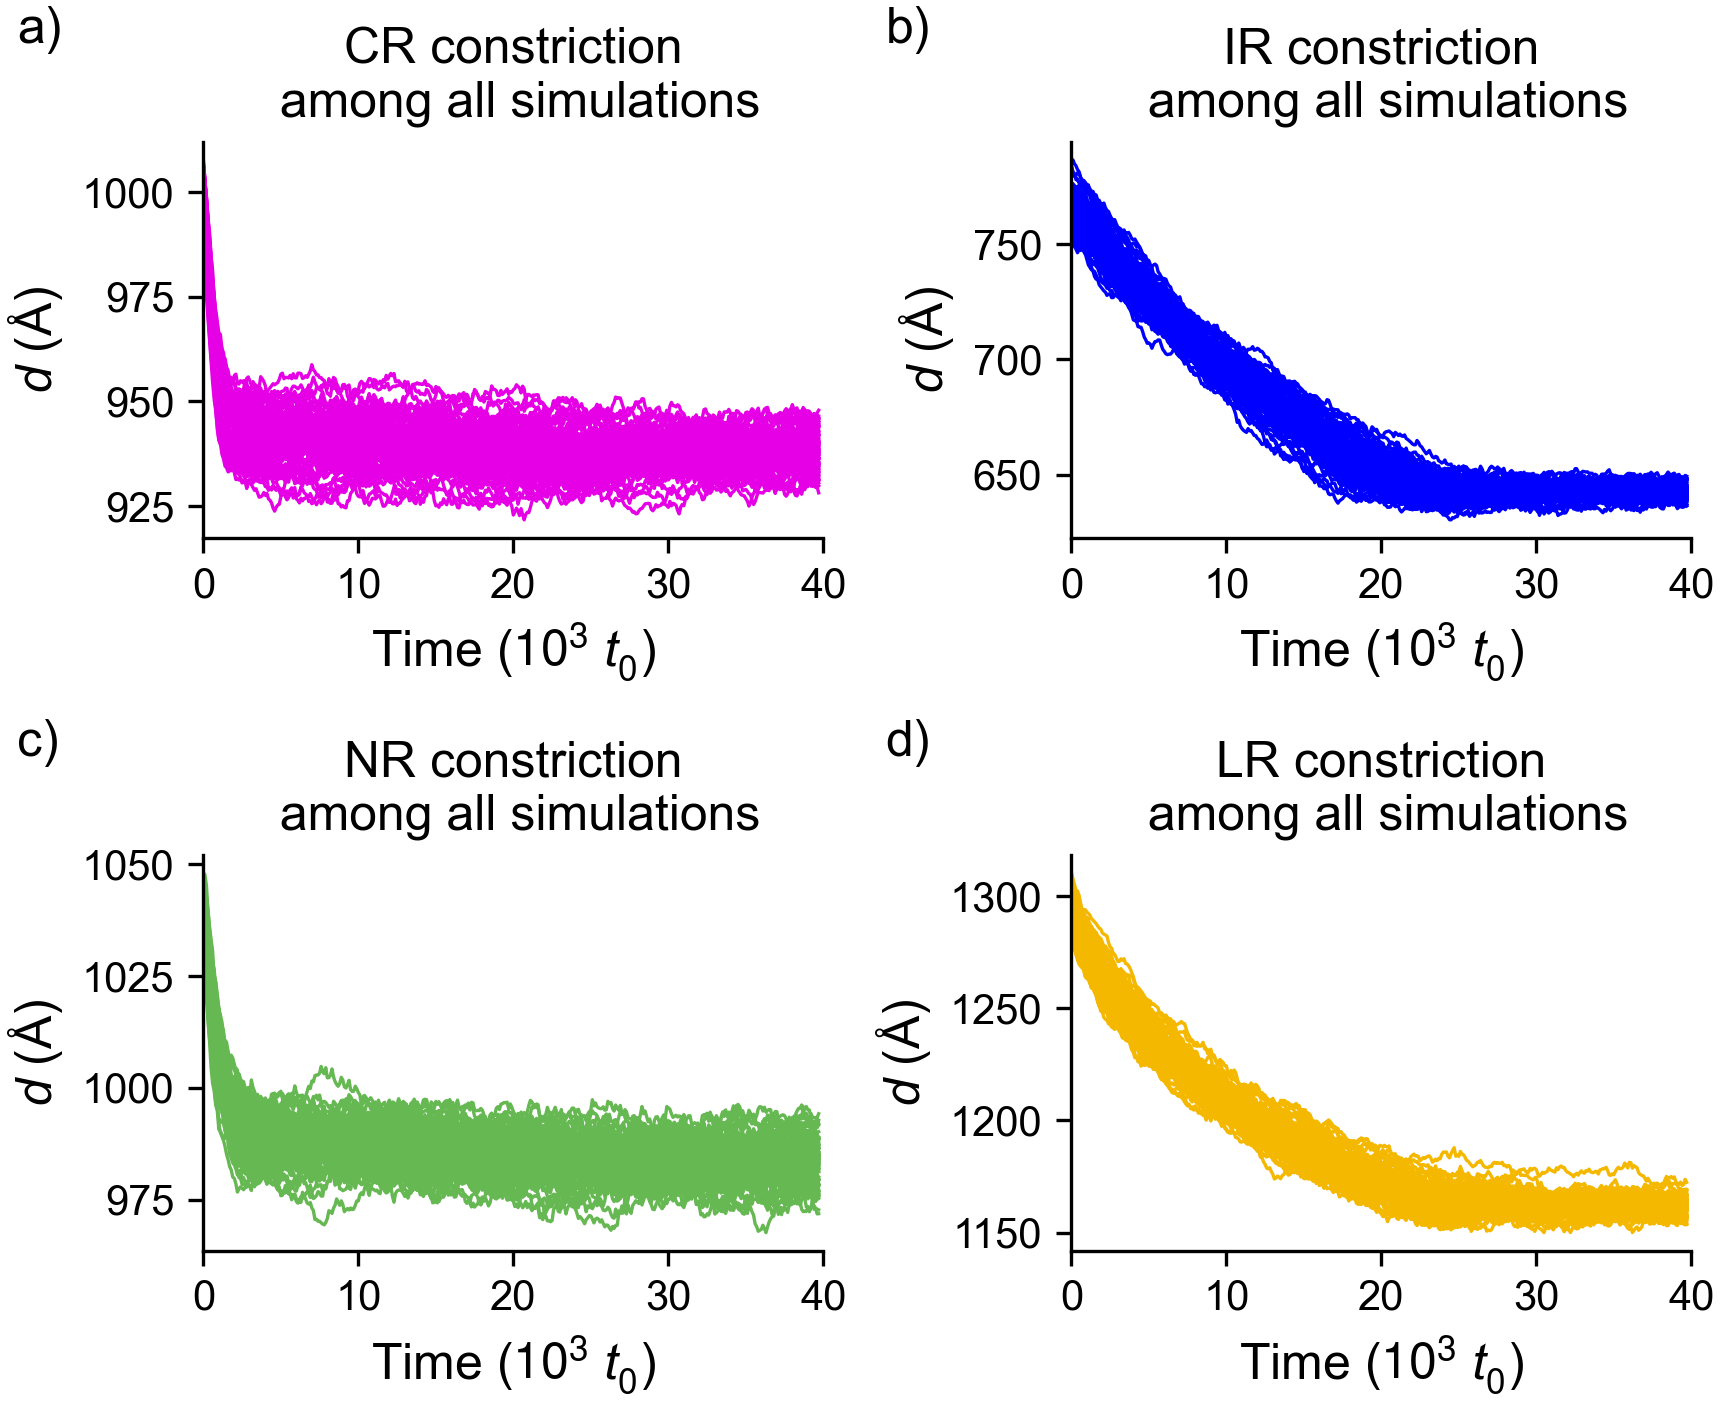

In [47]:
plt.figure(figsize=(6.4, 4.8))
for key in ('CR_all', 'IR_all', 'NR_all', 'LR_all'):
    d = np.hstack([get_diameter(ring_com_sim[key])[:end_frame] for ring_com_sim in ring_com_d2c[1:]])

    plt.subplot(2, 2, list_ring.index(key) + 1)
    plt.plot(np.arange(end_frame, step=n_step) * dt, d[::n_step], label = key[:2], color = dic_ring[key], linewidth = 0.8)
    plt.title(f"{key[:2]} constriction\n among all simulations")
    plt.xlim(0, end_frame_xlim * dt)
    plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
    plt.ylabel(r"$d$ (Å)")
    # plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
    # plt.ylabel("Diameter (Å)")

    # remove top axis
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    label(f"{chr(ord('a') + list_ring.index(key))})", x = -0.3, y = 1.25)
    
# plt.ylim(0, 150)
plt.subplots_adjust(wspace=0.4, hspace=0.8)

# plt.tight_layout()
plt.savefig("Figures4pub/diameter_change_SI.svg")
plt.savefig("Figures4pub/diameter_change_SI.pdf")

## IR comparison

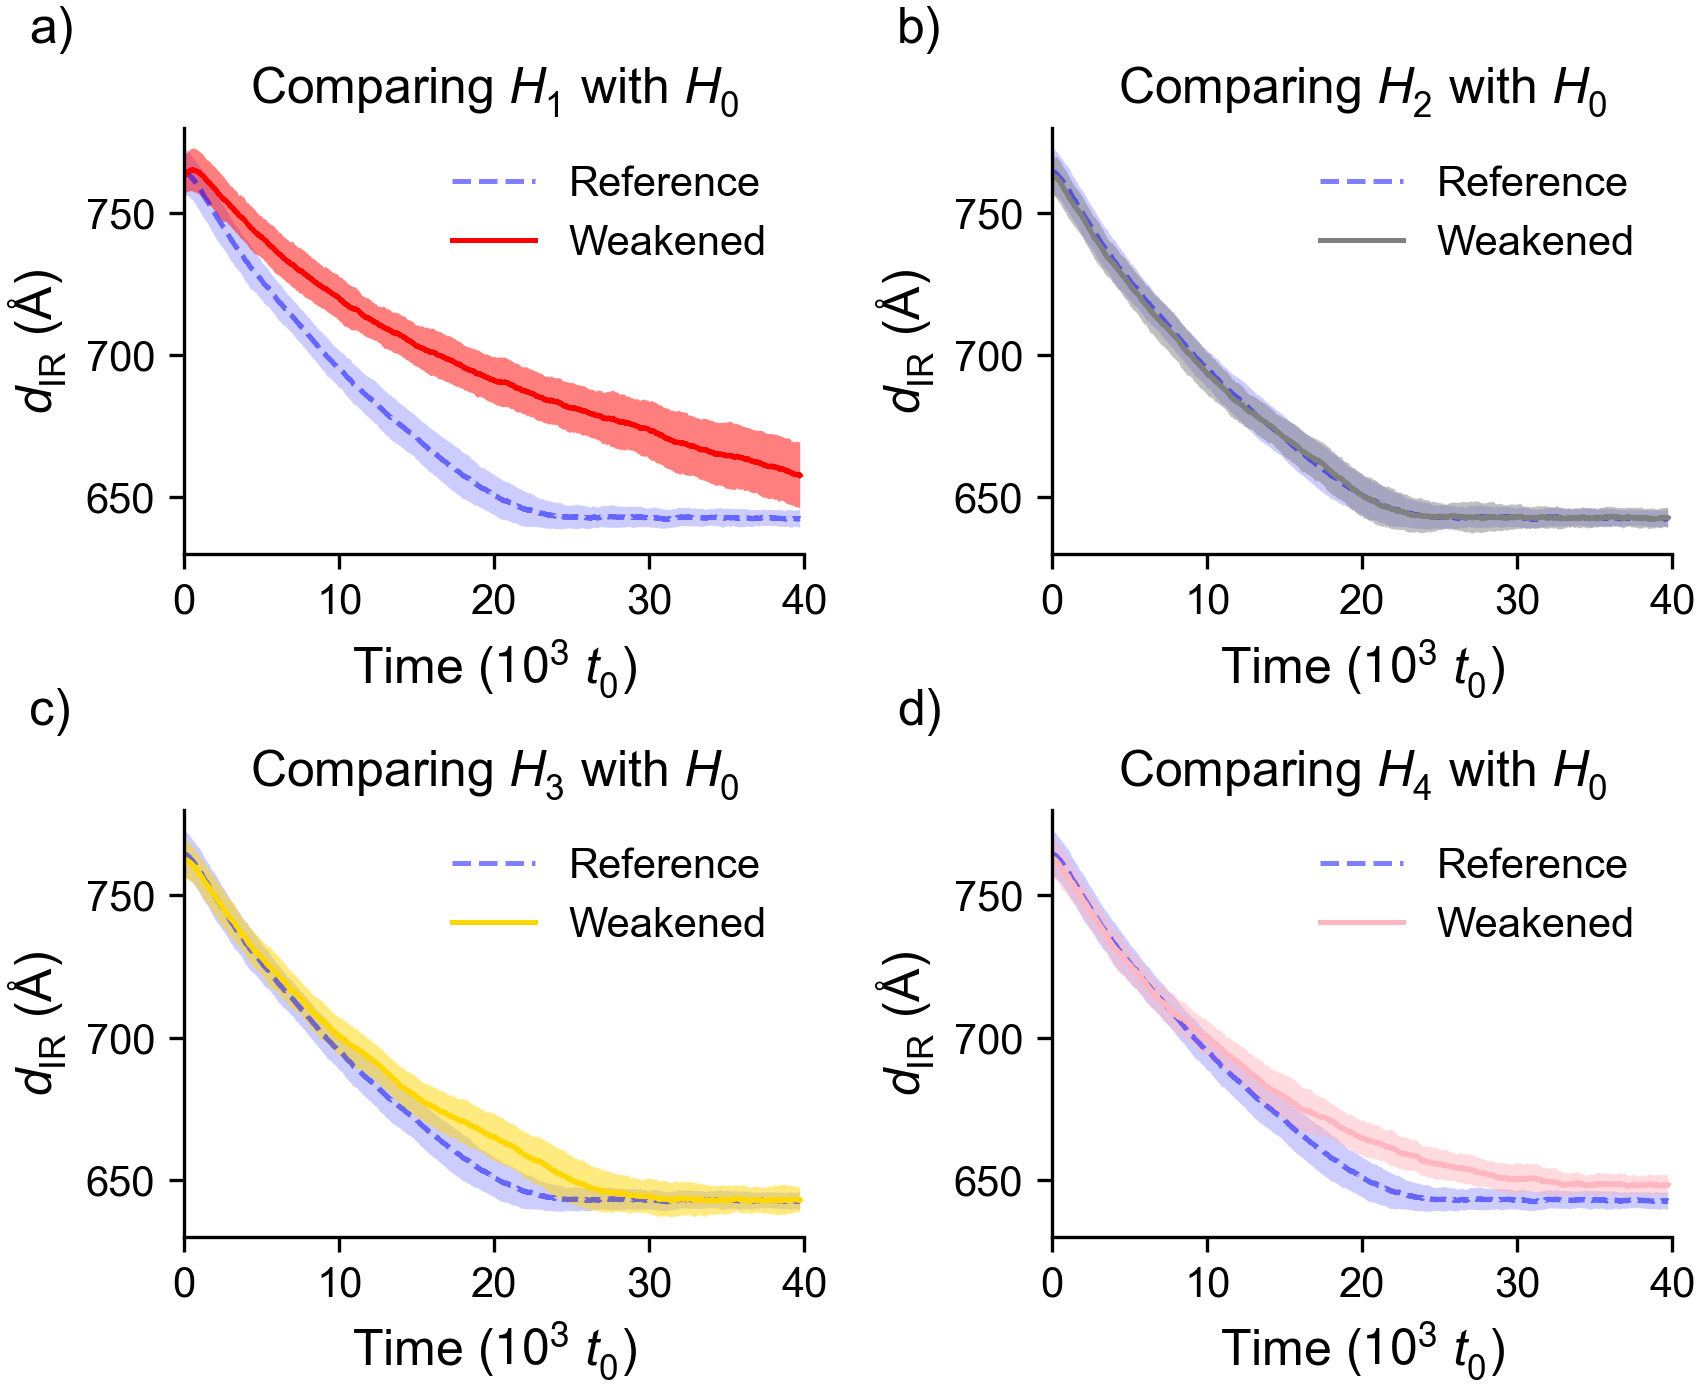

In [ ]:
key = 'IR_all'

plt.figure(figsize = (6.4, 4.8))


d_ref = np.hstack([get_diameter(ring_com_sim[key])[:end_frame] for ring_com_sim in ring_com_d2c[1:]])
d_ref_mean = d_ref.mean(axis = 1)
d_ref_std = d_ref.std(ddof = 1, axis = 1)

ring_com_list = [ring_com_intrachain_linker, ring_com_irnonlinker, ring_com_interchain_linker, ring_com_IRinterface]
# title_list = ['Intra-NUP Linker strength 10%', 'Intra-NUP non-linker\n in IR strength 10%', 'Inter-NUP Linker strength 10%', 'IR Interface strength 10%']
for sim_id in range(4):
    ring_com_ff = ring_com_list[sim_id]
    # title = title_list[sim_id]
    plt.subplot(2, 2, sim_id + 1)
    d = np.hstack([get_diameter(ring_com_sim[key])[:end_frame] for ring_com_sim in ring_com_ff[1:]])
    d_mean = d.mean(axis = 1)
    d_std = d.std(ddof = 1, axis = 1)

    plt.plot(np.arange(end_frame) * dt, d_ref_mean, color = dic_ring[key], linestyle = '--', alpha = 0.5, label = "Reference")
    plt.fill_between(
        np.arange(end_frame) * dt,
        d_ref_mean - d_ref_std,
        d_ref_mean + d_ref_std,
        facecolor = dic_ring[key], alpha = 0.2
    )

    plt.plot(np.arange(end_frame) * dt, d_mean, color = color_list[sim_id], label = "Weakened")
    plt.fill_between(
        np.arange(end_frame) * dt,
        d_mean - d_std,
        d_mean + d_std,
        facecolor = color_list[sim_id], alpha = 0.5
    )

    # remove axis
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # plt.legend(loc = [1.01, 0.2])
    plt.xlim(0, end_frame_xlim * dt)
    plt.ylim(630, 780)

    plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
    plt.ylabel(r"$d_{\mathrm{IR}}$ (Å)")
    plt.title(rf"Comparing $H_{{{sim_id+1}}}$ with $H_0$")
    plt.legend()
    label(f"{chr(ord('a') + sim_id)})", x = -0.25, y = 1.2)
plt.subplots_adjust(wspace=0.4, hspace=0.6)

# plt.tight_layout()

plt.savefig(f"Figures4pub/ir_diameter_change_comparison_SI.svg")
plt.savefig(f"Figures4pub/ir_diameter_change_comparison_SI.pdf")

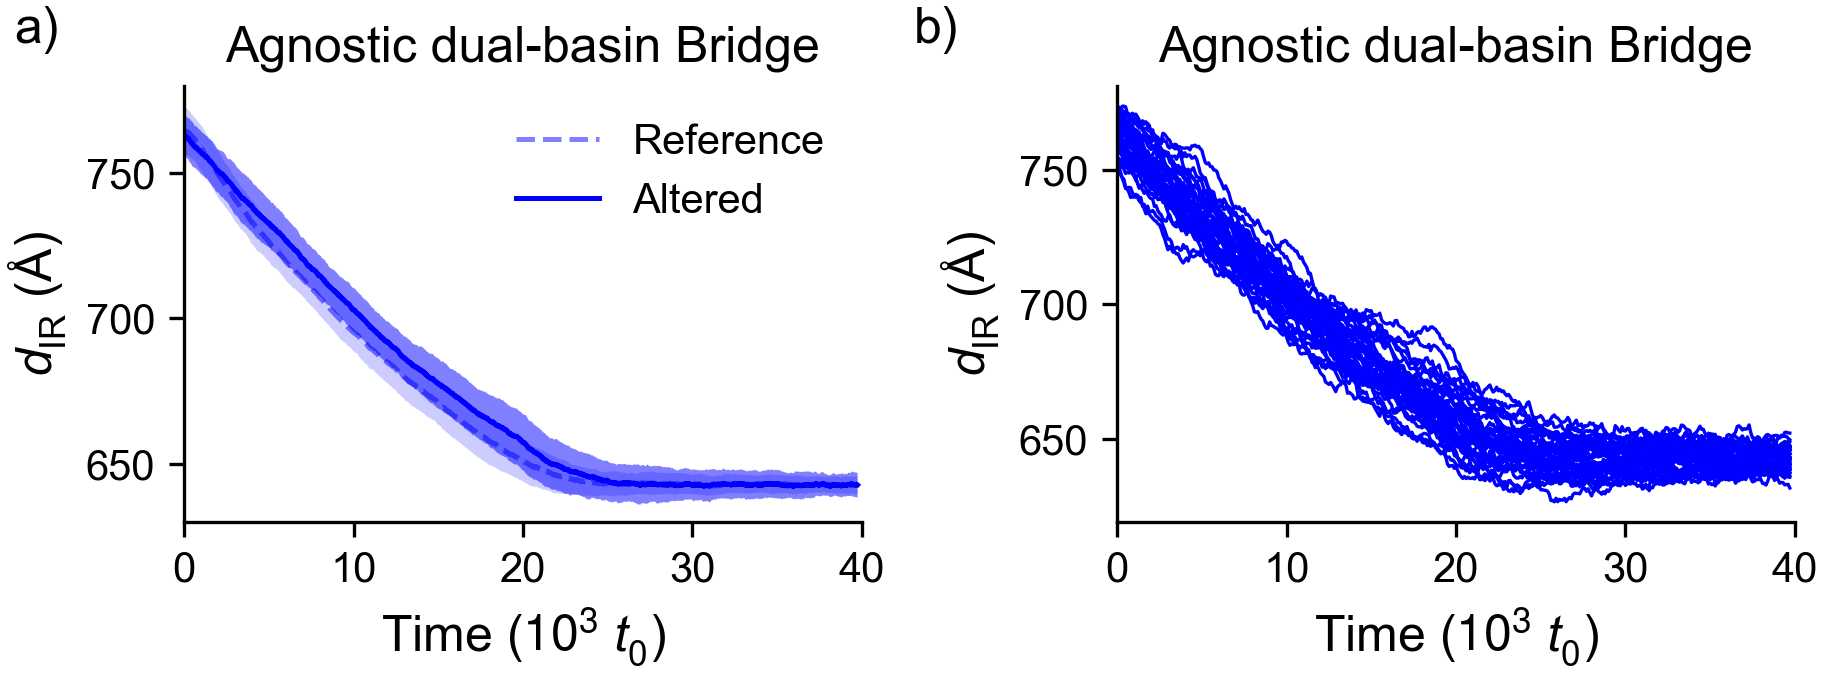

In [71]:
key = 'IR_all'

plt.figure(figsize = (6.4, 2.5))


d_ref = np.hstack([get_diameter(ring_com_sim[key])[:end_frame] for ring_com_sim in ring_com_d2c[1:]])
d_ref_mean = d_ref.mean(axis = 1)
d_ref_std = d_ref.std(ddof = 1, axis = 1)

ring_com_list = [ring_com_bridge_dual]
title_list = ['Agnostic dual-basin Bridge']

sim_id = 0
ring_com_ff = ring_com_list[sim_id]
title = title_list[sim_id]
d = np.hstack([get_diameter(ring_com_sim[key])[:end_frame] for ring_com_sim in ring_com_ff[1:]])
d_mean = d.mean(axis = 1)
d_std = d.std(ddof = 1, axis = 1)

plt.subplot(1, 2, 1)
plt.plot(np.arange(end_frame) * dt, d_ref_mean, color = dic_ring[key], alpha = 0.5, linestyle = '--', label = "Reference")
plt.fill_between(
    np.arange(end_frame) * dt,
    d_ref_mean - d_ref_std,
    d_ref_mean + d_ref_std,
    facecolor = dic_ring[key], alpha = 0.2
)

plt.plot(np.arange(end_frame) * dt, d_mean, color = dic_ring[key], label = "Altered")
plt.fill_between(
    np.arange(end_frame) * dt,
    d_mean - d_std,
    d_mean + d_std,
    facecolor = dic_ring[key], alpha = 0.5
)

# remove axis
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.legend(loc = [1.01, 0.2])
plt.xlim(0, end_frame_xlim * dt)
plt.ylim(630, 780)
plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
plt.ylabel(r"$d_{\mathrm{IR}}$ (Å)")
plt.title(title)
plt.legend()
label('a)', x = -0.25, y = 1.1)


plt.subplot(1, 2, 2)

plt.plot(np.arange(end_frame, step=n_step) * dt, d[::n_step], label = key[:2], color = dic_ring[key], linewidth = 0.8)
plt.title(title)
plt.xlim(0, end_frame_xlim * dt)
plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
plt.ylabel(r"$d_{\mathrm{IR}}$ (Å)")
# plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
# plt.ylabel("Diameter (Å)")

# remove top axis
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
label('b)', x = -0.3, y = 1.1)

# plt.subplots_adjust(wspace=0.4, hspace=0.6)

plt.tight_layout()

plt.savefig(f"Figures4pub/ir_diameter_dual_bridge_SI.svg")
plt.savefig(f"Figures4pub/ir_diameter_dual_bridge_SI.pdf")

# Intra-linker  

In [50]:
df_chain_info.query('Nup == "Nup35"')

,new_id,model,start,end,CA_start,CA_end,Nup,Chain ID,Ring
37,F0,7r5k,371088,372924,47163,47403,Nup35,LA,IR
38,F1,7r5k,372925,374761,47404,47644,Nup35,MA,IR
39,F2,7r5k,374762,376598,47645,47885,Nup35,NA,IR
40,F3,7r5k,376599,378435,47886,48126,Nup35,OA,IR


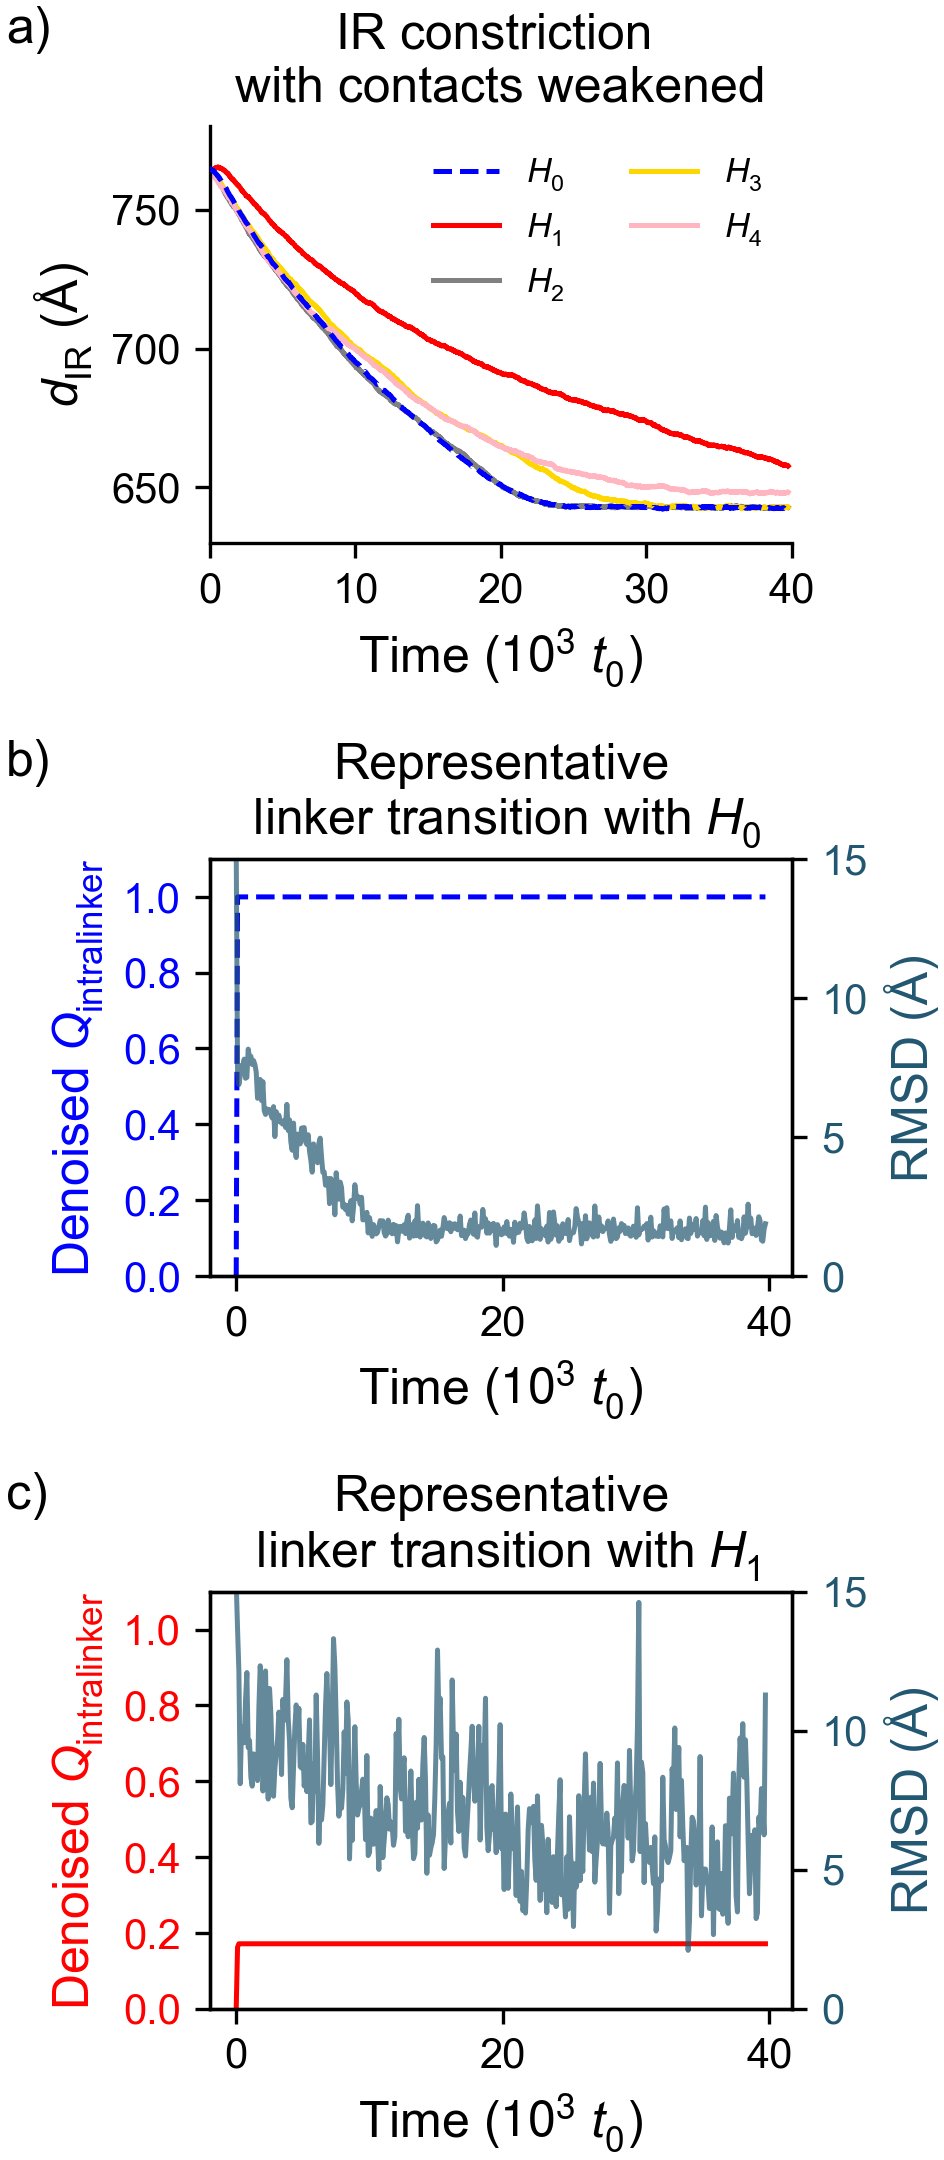

In [68]:
key = 'IR_all'

plt.figure(figsize = (3.5, 7.5))

plt.subplot(3, 1, 1)
d_ref = np.hstack([get_diameter(ring_com_sim[key])[:end_frame] for ring_com_sim in ring_com_d2c[1:]])
d_ref_mean = d_ref.mean(axis = 1)

plt.plot(np.arange(end_frame) * dt, d_ref_mean, color = dic_ring[key], linestyle = '--', label = r"$H_0$", zorder = 10)

color_list = ['red', 'gray', 'gold', 'lightpink']
ring_com_list = [ring_com_intrachain_linker, ring_com_irnonlinker, ring_com_interchain_linker, ring_com_IRinterface]
# title_list = ['Intra-NUP Linker strength 10%', 'Intra-NUP non-linker\n in IR strength 10%', 'Inter-NUP Linker strength 10%', 'IR Interface strength 10%']
for sim_id in range(4):
    ring_com_ff = ring_com_list[sim_id]
    d = np.hstack([get_diameter(ring_com_sim[key])[:end_frame] for ring_com_sim in ring_com_ff[1:]])
    d_mean = d.mean(axis = 1)

    plt.plot(np.arange(end_frame) * dt, d_mean, color = color_list[sim_id], label = rf"$H_{{{sim_id+1}}}$")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlim(0, end_frame_xlim * dt)
plt.ylim(630, 780)
plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
plt.ylabel(r"$d_{\mathrm{IR}}$ (Å)")
plt.title("IR constriction \nwith contacts weakened")
plt.legend(ncol = 2, fontsize = 8)

label('a)', x = -0.35, y = 1.2)

plt.subplot(3, 1, 2)
interface_idx = 2

q_form_tmp = d2c_q_form[1].df_Q.query(
    f'(chainids == "OA-OA" & subunit_i == {interface_idx} )'
)
Q_denoised = get_denoised_Q(q_form_tmp, end_frame)
plt.plot(np.arange(end_frame, step=n_step) * dt, Q_denoised[::n_step], color = "b", linestyle = '--')
plt.ylim(0, 1.1)
plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
plt.ylabel(r"Denoised $Q_{\mathrm{intralinker}}$", color = "b")
plt.tick_params(axis = 'y', labelcolor = "b")
plt.yticks(np.arange(0, 1.1, 0.2))

plt.twinx()

plt.plot(np.arange(end_frame, step=n_step) * dt, rmsd_linkers[:end_frame:n_step, 3, interface_idx], alpha = 0.7, color = spoke_color[interface_idx])
# plt.plot(np.arange(end_frame, step=n_step) * dt, rmsd_linkers[:end_frame:n_step, 0:2, interface_idx+1], alpha = 0.7)
plt.ylabel("RMSD (Å)", color = spoke_color[interface_idx])
plt.tick_params(axis = 'y', labelcolor = spoke_color[interface_idx])
plt.title(f"Representative\n linker transition with $H_0$")
plt.ylim(0, 15)

label('b)', x = -0.35, y = 1.2)

plt.subplot(3, 1, 3)
interface_idx = 2

q_form_tmp = intralinker_q_form[1].df_Q.query(
    f'(chainids == "OA-OA" & subunit_i == {interface_idx} )'
)
Q_denoised = get_denoised_Q(q_form_tmp, end_frame)
plt.plot(np.arange(end_frame, step=n_step) * dt, Q_denoised[::n_step], color = "red")
plt.ylim(0, 1.1)
plt.xlabel(r"Time ($\mathsf{10^3}~t_0$)")
plt.ylabel(r"Denoised $Q_{\mathrm{intralinker}}$", color = "red")
plt.tick_params(axis = 'y', labelcolor = "red")
plt.yticks(np.arange(0, 1.1, 0.2))

plt.twinx()

plt.plot(np.arange(end_frame, step=n_step) * dt, rmsd_linkers_intralinker[:end_frame:n_step, 3, interface_idx], alpha = 0.7, color = spoke_color[interface_idx])
# plt.plot(np.arange(end_frame, step=n_step) * dt, rmsd_linkers[:end_frame:n_step, 0:2, interface_idx+1], alpha = 0.7)
plt.ylabel("RMSD (Å)", color = spoke_color[interface_idx])
plt.tick_params(axis = 'y', labelcolor = spoke_color[interface_idx])
plt.title(f"Representative\n linker transition with $H_1$")
plt.ylim(0, 15)

label('c)', x = -0.35, y = 1.2)

# label(f"{chr(ord('a') + sim_id)})", x = -0.25, y = 1.2)
# fig.legend(["H_0", "H_1", "H_2", "H_3", "H_4"], loc = 'center', ncol = 3)

# plt.subplots_adjust(wspace=0.4, hspace=0.6)

plt.tight_layout()

plt.savefig(f"Figures4pub/ir_diameter_change_comparison.svg")

# Indices

In [60]:
def print4vmd(input):
    return("index " + " ".join(map(str, input)))

In [61]:
# For H1
q_form_tmp = d2c_q_form[1].df_Q.query(
    'nups == "Nup35-Nup35" & subunit_i == subunit_j & subunit_i == 0'
)
print(print4vmd(set(q_form_tmp[["i", "j"]].values.flatten())))

index 47168 47169 47173 47174 47175 47177 47178 47180 47181 47182 47183 47184 47185 47186 47187 47188 47189 47190 47191 47193 47194 47195 47196 47197 47198 47199 47200 47201 47202 47203 47204 47205 47206 47207 47208 47209 47210 47211 47212 47213 47214 47215 47216 47217 47218 47219 47220 47221 47222 47223 47224 47225 47226 47227 47228 47229 47230 47231 47232 47233 47234 47235 47236 47237 47238 47239 47240 47241 47242 47243 47244 47245 47246 47247 47248 47249 47250 47260 47263 47264 47267 47276 47277 47278 47279 47280 47281 47282 47283 47288 47291 47295 47299 47322 47323 47324 47327 47328 47329 47330 47331 47332 47333 47334 47335 47336 47337 47339 47341 47343 47344 47373 47374 47375 47376 47377 47378 47381 47382 47383 47384 47385 47413 47418 47419 47420 47423 47426 47427 47428 47431 47432 47434 47435 47436 47437 47438 47439 47440 47441 47443 47444 47445 47446 47447 47448 47450 47451 47452 47454 47456 47457 47458 47459 47460 47464 47467 47468 47469 47470 47471 47472 47473 47474 47475 4747

In [62]:
# For H2
q_form_tmp = d2c_q_form[1].df_Q.query(
    'nups != "Nup35-Nup35" & chainid_i == chainid_j & subunit_i == subunit_j & rings == "IR_all-IR_all" & subunit_i == 0'
)
print(print4vmd(set(q_form_tmp[["i", "j"]].values.flatten())))

index 20487 20490 20493 20496 43037 43039 43040 43041 43042 43043 43044 43045 43046 20519 43047 20521 20522 20523 38953 43053 43054 43055 43056 43057 43058 43059 43060 43061 43062 43064 43065 20540 38974 20543 20544 20545 38978 20547 20548 38980 38975 38979 20552 38983 38986 43153 43158 43159 43160 43164 43165 39100 39106 39107 39108 39109 39110 39113 39116 39119 39120 39121 39122 39123 39125 39126 43230 43231 39206 39207 39209 39210 39211 39213 39214 39216 39217 39219 39220 39221 39223 39224 39232 39235 39236 39238 39239 39240 39242 39243 39252 39291 39294 39295 39296 39297 20918 20921 20925 20932 20974 20976 20977 20978 20979 20981 20982 20983 20984 20989 20990 20993 20994 20995 20996 20997 20998 20999 21000 21001 21003 21004 21005 21006 21010 41526 41529 41533 39509 41577 41598 41599 41602 41603 41604 41606 41607 41729 41730 41731 41732 41733 41734 41735 41736 41737 41741 41743 41744 41745 41746 41748 41749 41750 41752 21311 21314 19281 19282 19285 19289 21337 21339 21340 21341 1929

In [63]:
# For H3
q_form_tmp = d2c_q_form[1].df_Q.query(
    '(nup_i == "Nup35" | nup_j == "Nup35") & ~(nup_i == "Nup35" & nup_j == "Nup35") & subunit_i == subunit_j & subunit_i == 0'
)
print(print4vmd(set(q_form_tmp[["i", "j"]].values.flatten())))

index 40964 40965 40966 40967 47932 40969 40970 19467 19470 19471 38926 19475 38427 38428 38435 38947 41010 41011 21044 41012 21046 41014 41015 21050 47675 47677 47678 47689 47180 41550 41552 47188 47189 41556 22104 39000 39001 39003 21596 21597 21598 47199 47200 39004 39006 39007 39010 41052 41059 41569 41570 41571 21100 42254 42255 39037 41748 19083 19084 19085 41624 41625 41627 47860 47861 47863 48067 47792 47793 47794 48068 40117 41142 38583 39096 40120 40122 41143 41653 41654 41657 41658 38592 41660 41661 41050 41051 19147 47310 38609 38610 38611 38612 47828 47827 47829 47832 48075 47835 47836 47837 47838 47839 48077 42212 42213 42216 42217 47851 47852 47853 47854 47855 47339 48080 47346 47859 47347 47348 47349 47351 47350 47352 47354 47862 47356 47357 47358 47359 47360 47865 41213 42220 18697 18698 47371 18699 18700 47372 47373 18701 47377 18704 47379 47380 47378 47382 47383 47374 47375 47381 41234 41235 41236 41754 47905 47906 47907 38690 38691 47910 47911 47912 47918 47920 4792

In [64]:
# For H4
q_form_tmp = d2c_q_form[1].df_Q.query(
    'rings == "IR_all-IR_all" & subunit_i == 0 & subunit_j == 1'
)
print(print4vmd(set(q_form_tmp[["i", "j"]].values.flatten())))

index 41475 30729 116746 30730 116748 30731 30732 49175 41497 49178 47645 116790 106576 106579 106580 50774 106583 106584 50777 106586 106587 50778 50780 106590 106591 50781 106096 106098 106099 125555 106101 106102 125554 106105 106106 116879 116881 106654 116898 106672 26319 26320 26321 26323 26324 26327 26328 26331 106735 106739 41206 41207 41208 106747 106748 106749 106750 106751 106752 125193 26390 26391 127772 127774 127775 127776 127777 127779 30557 30561 30564 30565 30567 30568 50087 50088 50090 30635 50091 50092 50093 50094 50095 30653 30655 128466 128469 30692 30694 30695 30709


# End